In [1]:
import pandas as pd


In [2]:
df = pd.read_csv('data/Colorado River Basin Water Conflict Table.csv')

In [3]:
df.shape

(268, 48)

In [5]:
df.isna().sum()

Event                                             0
Search Source                                     0
Newspaper                                         0
Article Title                                     0
Duplicate                                         1
Report Date                                       1
Report Year                                       3
Event Date                                       20
Event Day                                       250
Event Month                                      56
Event Year                                       11
Conflict Present                                 16
Crisis Present                                   14
Basin                                            18
HUC6                                            158
HUC2                                             18
Place                                            14
County                                          260
County FIPS                                     260
State       

In [6]:
df.head()

,Event,Search Source,Newspaper,Article Title,Duplicate,Report Date,Report Year,Event Date,Event Day,Event Month,...,Article Text Search - water rights,Article Text Search - intergovernmental,Article Text Search - water transfers,Article Text Search - navigation,Article Text Search - fish,Article Text Search - invasive,Article Text Search - diversion,Article Text Search - water diversion,Article Text Search - instream,Article Text Search - aquatic
0,1,USGS1-50.docx,The Durango Herald (Colorado),Tribes assert water rights on Colorado River B...,False,7-Apr-22,2022.0,NaN,NaN,4.0,...,17,0,0,0,0,0,0,0,0,0
1,2,USGS1-50.docx,"Journal, The (Cortez, Dolores, Mancos, CO)",Native American tribes assert water rights on ...,False,7-Apr-22,2022.0,NaN,NaN,4.0,...,17,0,0,0,0,0,0,0,0,0
2,3,USGS1-50.docx,The Salt Lake Tribune,'Very positive change.' New Utah law will be a...,False,17-Mar-22,2022.0,NaN,NaN,3.0,...,12,0,0,0,1,0,0,0,12,1
3,4,USGS1-50.docx,Casa Grande Dispatch (AZ),Legislation would let an Arizona tribe lease C...,False,11-Dec-21,2021.0,NaN,NaN,12.0,...,6,0,0,0,0,0,0,0,0,0
4,5,USGS1-50.docx,The Aspen Times (Colorado),Historically excluded from Colorado River poli...,False,19-Dec-21,2021.0,NaN,NaN,11.0,...,18,0,0,0,0,0,0,0,0,0


In [7]:
df.columns

Index(['Event', 'Search Source', 'Newspaper', 'Article Title', 'Duplicate',
       'Report Date', 'Report Year', 'Event Date', 'Event Day', 'Event Month',
       'Event Year', 'Conflict Present', 'Crisis Present', 'Basin', 'HUC6',
       'HUC2', 'Place', 'County', 'County FIPS', 'State', 'State FIPS',
       'Urban or Rural', 'Issue Type', 'Event Summary', 'Stakeholders',
       'Intensity Value', 'Comments', 'Related Observation Themes',
       'Article Text Search - water quality',
       'Article Text Search - invasive species',
       'Article Text Search - conservation', 'Article Text Search - drought',
       'Article Text Search - flood',
       'Article Text Search - ground water depletion',
       'Article Text Search - depletion',
       'Article Text Search - infrastructure',
       'Article Text Search - fish passage',
       'Article Text Search - instream water rights',
       'Article Text Search - water rights',
       'Article Text Search - intergovernmental',
       '

In [8]:
df['Issue Type'].value_counts()

Issue Type
Drought                                                                       66
Water rights more generally                                                   51
Conservation                                                                  43
Intergovernmental issues                                                      43
Infrastructure issues                                                         15
Water quality                                                                 10
Water transfers                                                                6
Instream water rights                                                          6
Flood                                                                          4
Intergovernmental issues: Water rights more generally                          2
Intergovernmental issues: Drought                                              1
Intergovernmental issues: Water transfers                                      1
Intergovernmental

In [11]:
df['Place'].unique()

array(['Durango, CO', 'Great Salt Lake',
       'Colorado River Indian Reservation',
       'Southern Ute Indian Reservation', 'State of Arizona',
       'Entire Colorado River Basin', 'All of Colorado River Basin',
       'Farmington, OH; Great Salt Lake', 'Navajo Nation; Window Rock AZ',
       'Bullhead City, AZ re: All of Colorado R. Basin', 'Phoenix, AZ',
       'Ute Tribe, Utah', 'Denver, CO; Shoshone power plant',
       'AZ, CO, NM, UT, Southern Ute Tribe, Ute Mountain tribe, Navajo Nation',
       'Colorado River Basin', 'Laughlin, AZ',
       'Colorado River Indian Reservation; Parker, AZ',
       'CA - Imperial Irrigation District', 'Flagstaff, AZ',
       'Glen Canyon Dam, Lake Powell, UT; AZ', 'Needles, CA',
       'AZ, NV, Mexico', 'CO, UT, WY, NM', 'Las Vegas, Southern CA; AZ',
       'Sacaton/Gila R. Indian Reservation', 'Boulder, CO', 'Lees Ferry',
       'AZ', 'Lake Powell (UT, AZ)', 'Glenwod Springs',
       'Multiple waterways in UT ', 'St. Michaels, AZ',
       'Th

### string accessor

In [12]:
# CELL 1
import numpy as np

# Example series
s = pd.Series(['California; Nevada', 'Arizona', np.nan, 'Nevada; Utah'])
s

0    California; Nevada
1               Arizona
2                   NaN
3          Nevada; Utah
dtype: object

In [14]:
# CELL 3
# Use str accessor with additional methods to perform string operations
split = s.str.split(';')

In [15]:
split.explode()

0    California
0        Nevada
1       Arizona
2           NaN
3        Nevada
3          Utah
dtype: object

In [16]:
df['State']

0          CO
1          CO
2          UT
3         NaN
4         NaN
        ...  
263        CO
264        CO
265    AZ; CA
266        AZ
267        AZ
Name: State, Length: 268, dtype: object

In [17]:

df['State'].str.split(';').explode()

0       CO
1       CO
2       UT
3      NaN
4      NaN
      ... 
264     CO
265     AZ
265     CA
266     AZ
267     AZ
Name: State, Length: 320, dtype: object

In [20]:
df['State'].notna()

0       True
1       True
2       True
3      False
4      False
       ...  
263     True
264     True
265     True
266     True
267     True
Name: State, Length: 268, dtype: bool

In [33]:
conflict = df.loc[df['Conflict Present'] == "Y", 'State'].str.split(';').explode()

In [34]:
conflict.unique()

array(['CO', nan, 'AZ', 'OH', ' UT', 'UT', 'CA', ' NV', ' WY', ' NM',
       ' CA', 'NV', ' AZ', ' CO', 'NM', 'WY'], dtype=object)

In [37]:
conflict.str.strip().unique()

array(['CO', nan, 'AZ', 'OH', 'UT', 'CA', 'NV', 'WY', 'NM'], dtype=object)

In [38]:
conflict = df.loc[df['Conflict Present'] == "Y", 'State'].str.split(';').explode().str.strip()

In [51]:
conflict_count = conflict.value_counts(dropna = False)

<Axes: title={'center': 'Water Conflicts in Each State'}, xlabel='State', ylabel='Conflict Count'>

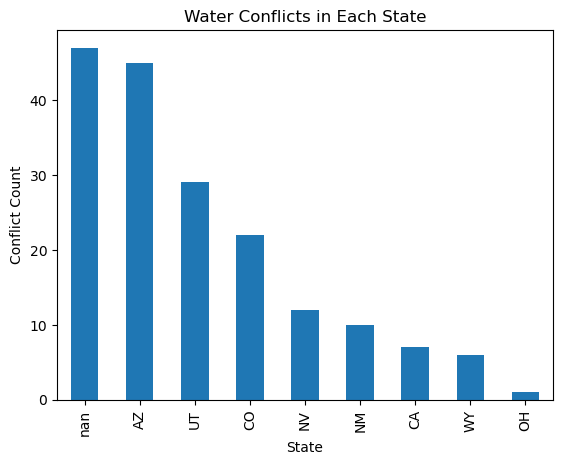

In [56]:
conflict_count.plot(kind = "bar", ylabel = "Conflict Count", title = "Water Conflicts in Each State")

The plot shows that most entries actually have not been given a state value. We also can see that of the recorded states, Arizona has the most recorded woater conflicts, followed by Utah and Colorado.